# Speed benchmark

Visualizes per-config JSON files written by `scripts/bench_speed.py` into
`results/bench_speed/`. Each file is one (backend, image size, batch size,
max_new_tokens) config; `baseline` = no optimizations at all (not even mask
caching). Every `status: "ok"` row was structurally verified with
`check_accel` before timing; `status: "error"` rows record a config that
failed (e.g. missing flash-attn) without aborting the rest of the sweep.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("../results/bench_speed")
records = [json.loads(p.read_text()) for p in sorted(RESULTS.glob("*.json"))]
print(f"{len(records)} config files")
print(
    json.dumps(
        {
            k: records[0][k]
            for k in (
                "model_id",
                "device",
                "dtype",
                "torch",
                "transformers",
                "timestamp",
            )
        },
        indent=2,
    )
)
df = pd.json_normalize(records)
df_ok = df[df.status == "ok"].copy()
df

6 config files
{
  "model_id": "tiny-random-donut",
  "device": "cpu",
  "dtype": "bfloat16",
  "torch": "2.12.0+cu130",
  "transformers": "5.12.1",
  "timestamp": "2026-06-19T11:54:44+00:00"
}


,model_id,device,dtype,torch,transformers,timestamp,backend,image_height,image_width,batch_size,...,encoder.times,encoder.images_per_s,generate.mean_ms,generate.std_ms,generate.p50_ms,generate.p95_ms,generate.n_runs,generate.times,generate.new_tokens,generate.tokens_per_s
0,tiny-random-donut,cpu,bfloat16,2.12.0+cu130,5.12.1,2026-06-19T11:54:44+00:00,baseline,64,64,1,...,"[7.397956011118367, 7.086763012921438]",138.083,16.906,0.016,16.922,16.922,2,"[16.922253009397537, 16.889592006918974]",4.0,236.602
1,tiny-random-donut,cpu,bfloat16,2.12.0+cu130,5.12.1,2026-06-19T11:54:15+00:00,baseline,64,64,2,...,"[16.352954000467435, 16.070832003606483]",123.365,39.029,1.039,40.068,40.068,2,"[37.98975999234244, 40.06825599935837]",4.0,204.976
2,tiny-random-donut,cpu,bfloat16,2.12.0+cu130,5.12.1,2026-06-19T11:54:15+00:00,eager,64,64,1,...,"[11.093651002738625, 10.839437993126921]",91.183,33.258,1.130,34.387,34.387,2,"[32.128154998645186, 34.38724200532306]",4.0,120.272
3,tiny-random-donut,cpu,bfloat16,2.12.0+cu130,5.12.1,2026-06-19T11:54:15+00:00,eager,64,64,2,...,"[23.91467199777253, 30.568103000405245]",73.419,38.186,1.866,40.051,40.051,2,"[40.05143999529537, 36.32017799827736]",4.0,209.501
4,tiny-random-donut,cpu,bfloat16,2.12.0+cu130,5.12.1,2026-06-19T11:54:15+00:00,sdpa,64,64,1,...,"[9.112960993661545, 8.394973003305495]",114.233,31.404,1.677,33.081,33.081,2,"[29.727183005888946, 33.080520006478764]",4.0,127.372
5,tiny-random-donut,cpu,bfloat16,2.12.0+cu130,5.12.1,2026-06-19T11:54:15+00:00,sdpa,64,64,2,...,"[10.738333003246225, 10.404814995126799]",189.179,33.203,1.004,34.207,34.207,2,"[32.19917199749034, 34.207143005914986]",4.0,240.942


## Pick one (size, max_new_tokens) slice to plot

The bar/line charts below compare backends at a single image size and
`max_new_tokens` (varying batch size on the x-axis). Defaults to the first
slice present in the data — change `SLICE` to inspect a different one.

In [2]:
SLICE = df_ok[["image_height", "image_width", "max_new_tokens"]].iloc[0].to_dict()
print("plotting slice:", SLICE)
mask = (
    (df_ok.image_height == SLICE["image_height"])
    & (df_ok.image_width == SLICE["image_width"])
    & (df_ok.max_new_tokens == SLICE["max_new_tokens"])
)
sl = df_ok[mask]

plotting slice: {'image_height': 64, 'image_width': 64, 'max_new_tokens': 4}


## Encoder latency per backend (p95 whiskers)

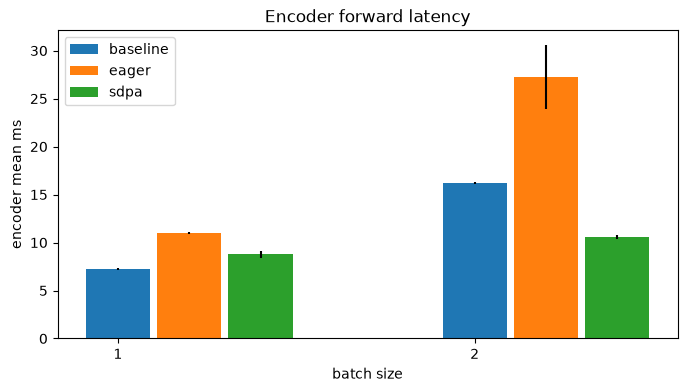

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, (backend, g) in enumerate(sl.groupby("backend", sort=False)):
    g = g.sort_values("batch_size")
    x = [j + i * 0.2 for j in range(len(g))]
    err = g["encoder.p95_ms"] - g["encoder.mean_ms"]
    ax.bar(x, g["encoder.mean_ms"], width=0.18, yerr=err.clip(lower=0), label=backend)
ax.set_xticks(range(sl.batch_size.nunique()))
ax.set_xticklabels(sorted(sl.batch_size.unique()))
ax.set_xlabel("batch size")
ax.set_ylabel("encoder mean ms")
ax.legend()
ax.set_title("Encoder forward latency")
plt.show()

## Generation throughput and speedup vs baseline

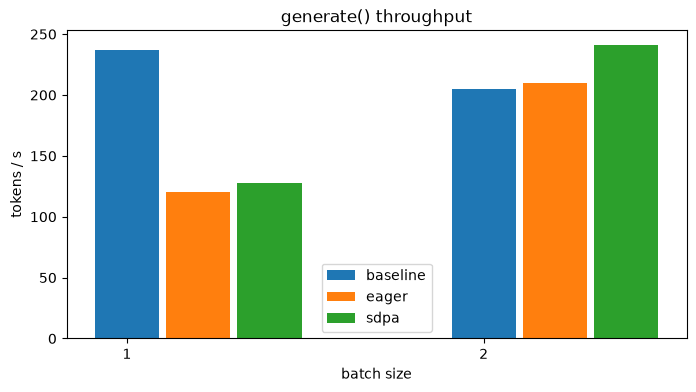

speedup_vs_baseline.encoder           speedup_vs_baseline.generate  \
batch_size                           1         2                            1   
backend                                                                         
baseline                      1.000000  1.000000                     1.000000   
eager                         0.660345  0.595132                     0.508329   
sdpa                          0.827279  1.533485                     0.538339   

                      
batch_size         2  
backend               
baseline    1.000000  
eager       1.022076  
sdpa        1.175466

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, (backend, g) in enumerate(sl.groupby("backend", sort=False)):
    g = g.sort_values("batch_size")
    x = [j + i * 0.2 for j in range(len(g))]
    ax.bar(x, g["generate.tokens_per_s"], width=0.18, label=backend)
ax.set_xticks(range(sl.batch_size.nunique()))
ax.set_xticklabels(sorted(sl.batch_size.unique()))
ax.set_xlabel("batch size")
ax.set_ylabel("tokens / s")
ax.legend()
ax.set_title("generate() throughput")
plt.show()

group_cols = ["image_height", "image_width", "batch_size", "max_new_tokens"]
baseline = df_ok[df_ok.backend == "baseline"].set_index(group_cols)
speedup = df_ok.set_index(group_cols).join(
    baseline[["encoder.mean_ms", "generate.mean_ms"]], rsuffix="_baseline"
)
speedup["speedup_vs_baseline.encoder"] = (
    speedup["encoder.mean_ms_baseline"] / speedup["encoder.mean_ms"]
)
speedup["speedup_vs_baseline.generate"] = (
    speedup["generate.mean_ms_baseline"] / speedup["generate.mean_ms"]
)
speedup.reset_index().pivot_table(
    index="backend",
    columns="batch_size",
    values=["speedup_vs_baseline.encoder", "speedup_vs_baseline.generate"],
)

## Batch-size scaling

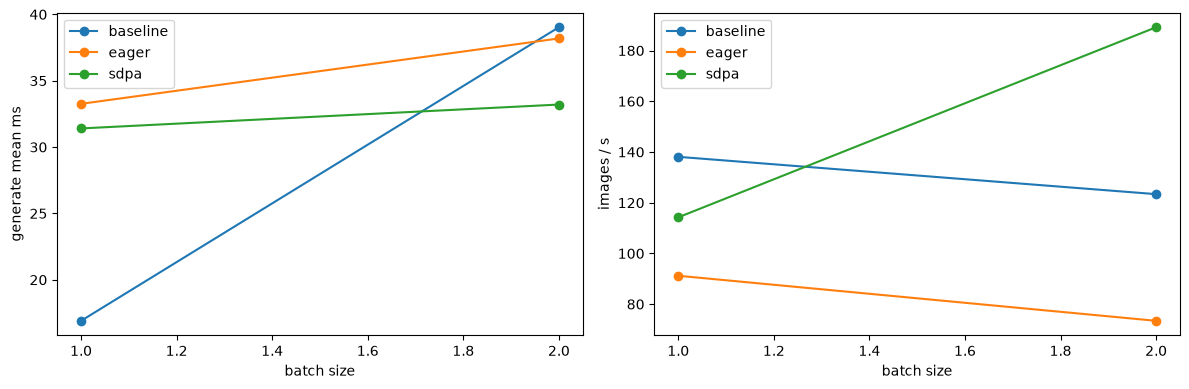

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for backend, g in sl.groupby("backend", sort=False):
    g = g.sort_values("batch_size")
    axes[0].plot(g.batch_size, g["generate.mean_ms"], marker="o", label=backend)
    axes[1].plot(g.batch_size, g["encoder.images_per_s"], marker="o", label=backend)
axes[0].set_ylabel("generate mean ms")
axes[1].set_ylabel("images / s")
for ax in axes:
    ax.set_xlabel("batch size")
    ax.legend()
plt.tight_layout()
plt.show()

## Notes

- CPU numbers are noisy and only useful as smoke checks; trust CUDA runs with
  `n_runs >= 10`.
- Results accumulate in `results/bench_speed/` across separate sweep
  invocations — re-running `bench_speed.py` skips configs whose file already
  exists (use `--force` to recompute). Filenames only encode the swept axes
  (backend/size/batch/max_new_tokens), so switching `--dtype`/`--device`/
  `--model-id` between runs that share the same `--out` folder will collide
  with prior results under those names — use a separate `--out` folder per
  (model_id, device, dtype) if you need to keep them apart.
- `status: "error"` rows (e.g. a backend unavailable on this machine) show up
  in `df` but are excluded from `df_ok` and all plots above.
- Adding a new backend: add a preset in `donut/accel/__init__.py`, then
  `--backends baseline,eager,sdpa,<new>` — the JSON schema and this notebook
  pick it up unchanged.